In [63]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
import matplotlib.pyplot as plt
import seaborn as sns
# Read data
data = pd.read_csv('student_lifestyle_dataset.csv')
data.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [64]:
# Preprocessing
# Drop columns we don't need
data.drop(['Student_ID'],axis=1,inplace=True) 

# Drop nan rows
data.dropna(inplace=True) 
ordenc = OrdinalEncoder(categories=[['Low','Moderate','High']])
data[['Stress_Level']] = ordenc.fit_transform(data[['Stress_Level']])+1

data.head()

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,6.9,3.8,8.7,2.8,1.8,2.99,2.0
1,5.3,3.5,8.0,4.2,3.0,2.75,1.0
2,5.1,3.9,9.2,1.2,4.6,2.67,1.0
3,6.5,2.1,7.2,1.7,6.5,2.88,2.0
4,8.1,0.6,6.5,2.2,6.6,3.51,3.0


In [65]:
X = data[['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']].values
y = data['Stress_Level'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = RandomForestClassifier(n_estimators=5, random_state=42)
model.fit(X_train, y_train)
# Evaluate the model
scores = cross_val_score(model, X_train, y_train, cv=KFold(n_splits=10, shuffle=True, random_state=42))
print(f'Cross-validation scores: {scores}')
print(f'Mean cross-validation score: {scores.mean()}')


Cross-validation scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean cross-validation score: 1.0


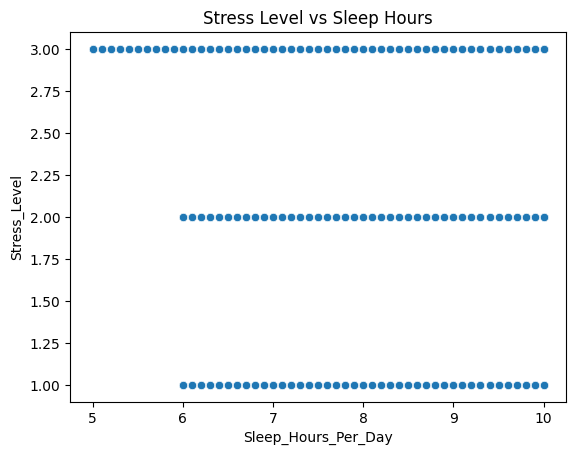

In [66]:
sns.scatterplot(x='Sleep_Hours_Per_Day', y='Stress_Level', data=data)
plt.title("Stress Level vs Sleep Hours")
plt.show()

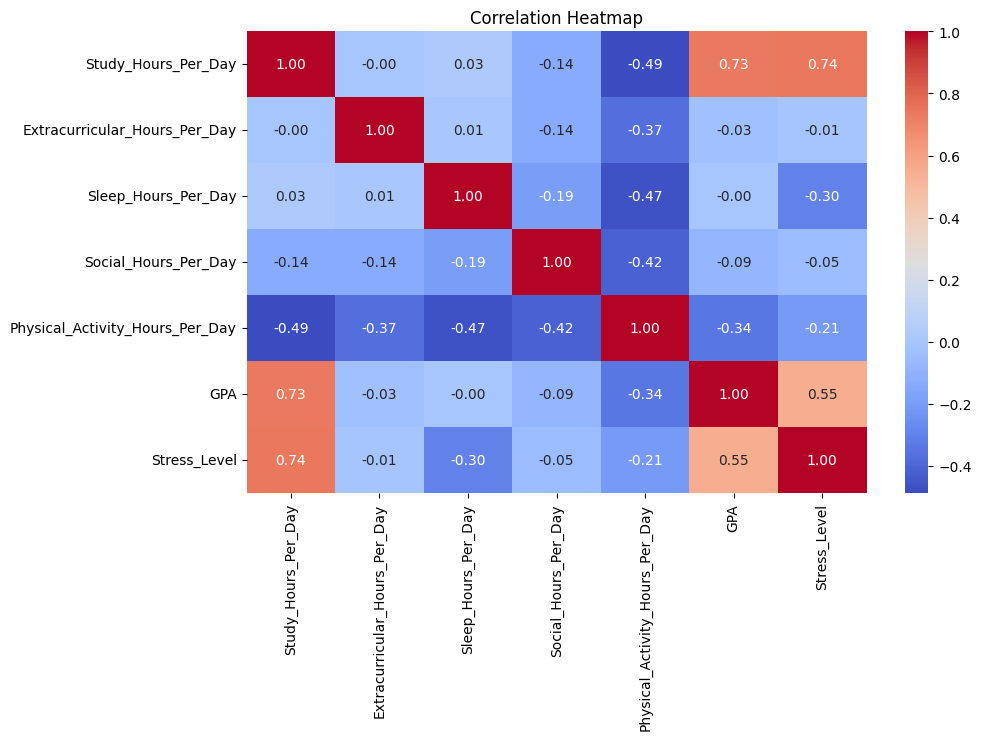

In [67]:
plt.figure(figsize=(10,6))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()